<a href="https://colab.research.google.com/github/jelaenas/CESISTA-KJ-DSC1107/blob/main/CESISTA_SA_1_DSC1107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("caret")
install.packages("glmnet")
install.packages("rpart")
install.packages("rpart.plot")
install.packages("randomForest")
library(tidyverse)
library(caret)
library(glmnet)
library(rpart)
library(rpart.plot)
library(randomForest)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubr

In [48]:
install.packages("effects")
library(effects)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘mitools’, ‘RcppArmadillo’, ‘carData’, ‘lme4’, ‘colorspace’, ‘survey’, ‘estimability’, ‘insight’


Loading required package: carData

Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.



# **Unit 1: R for Data Mining**
1.   **Intro to Modern Data Mining**
*   Load the dataset and provide an overview of its structure (e.g., dimensions, missing values, types of variables).
*   Explain why data mining is important for this dataset.

In [37]:
customer_churn <- read.csv("customer_churn.csv")

In [27]:
dim(customer_churn)
glimpse(customer_churn)
summary(customer_churn)
sapply(customer_churn, function(x) sum(is.na(x)))
sum(duplicated(customer_churn$CustomerID))

[1] 10000    12

Rows: 10,000
Columns: 12
$ CustomerID      <chr> "CUST00001", "CUST00002", "CUST00003", "CUST00004", "C…
$ Gender          <chr> "Male", "Male", "Male", "Female", "Male", "Female", "F…
$ SeniorCitizen   <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, …
$ Partner         <chr> "No", "No", "Yes", "Yes", "No", "No", "Yes", "Yes", "Y…
$ Dependents      <chr> "No", "No", "No", "Yes", "No", "Yes", "No", "Yes", "Ye…
$ Tenure          <int> 65, 26, 54, 70, 53, 45, 35, 20, 48, 33, 33, 39, 6, 51,…
$ PhoneService    <chr> "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"…
$ InternetService <chr> "Fiber optic", "Fiber optic", "Fiber optic", "DSL", "D…
$ Contract        <chr> "Month-to-month", "Month-to-month", "Month-to-month", …
$ MonthlyCharges  <dbl> 20.04, 65.14, 49.38, 31.19, 103.86, 87.34, 119.91, 69.…
$ TotalCharges    <dbl> 1302.60, 1693.64, 2666.52, 2183.30, 5504.58, 3930.30, …
$ Churn           <chr> "No", "No", "No", "No", "Yes", "Yes", "Yes", "Yes", "N…


  CustomerID           Gender          SeniorCitizen      Partner         
 Length:10000       Length:10000       Min.   :0.0000   Length:10000      
 Class :character   Class :character   1st Qu.:0.0000   Class :character  
 Mode  :character   Mode  :character   Median :0.0000   Mode  :character  
                                       Mean   :0.1502                     
                                       3rd Qu.:0.0000                     
                                       Max.   :1.0000                     
  Dependents            Tenure      PhoneService       InternetService   
 Length:10000       Min.   : 0.00   Length:10000       Length:10000      
 Class :character   1st Qu.:17.00   Class :character   Class :character  
 Mode  :character   Median :35.00   Mode  :character   Mode  :character  
                    Mean   :35.22                                        
                    3rd Qu.:53.00                                        
                    Max.   :71.

CustomerID          Gender   SeniorCitizen         Partner      Dependents 
              0               0               0               0               0 
         Tenure    PhoneService InternetService        Contract  MonthlyCharges 
              0               0               0               0               0 
   TotalCharges           Churn 
              0               0

[1] 0

**Explain why data mining is important for this dataset.**

Data mining is important for this dataset as it allows for better analysis of customer behavior. It gives insight on customer churn, and the reasons why certain customers may stop subscribing to their service. This will allow the company to predict churn and create strategies to prevent customer churn.

2. **Data Visualization**

* Create at least three meaningful visualizations to explore relationships in the data (e.g., churn rate by tenure, service type, or monthly charges).

* Provide insights based on the visualizations.

Across all three plots, churn rate stays pretty consistent (at around 25-30%) and there are barely any fluctuations.

Churn Rate by Tenure shows that churn rate hovers around the same percentage regardless of how many months they have been using the services.

Churn Rate by Service Type has churn rate very close to each other, this shows that service type is unlikely to cause customers to discontinue using the services provided



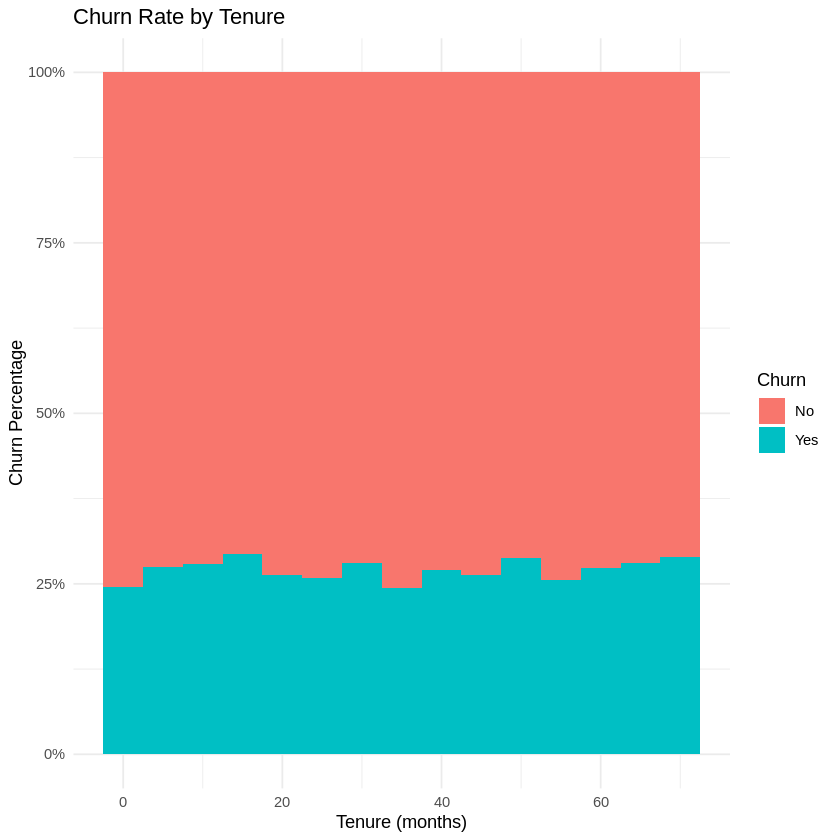

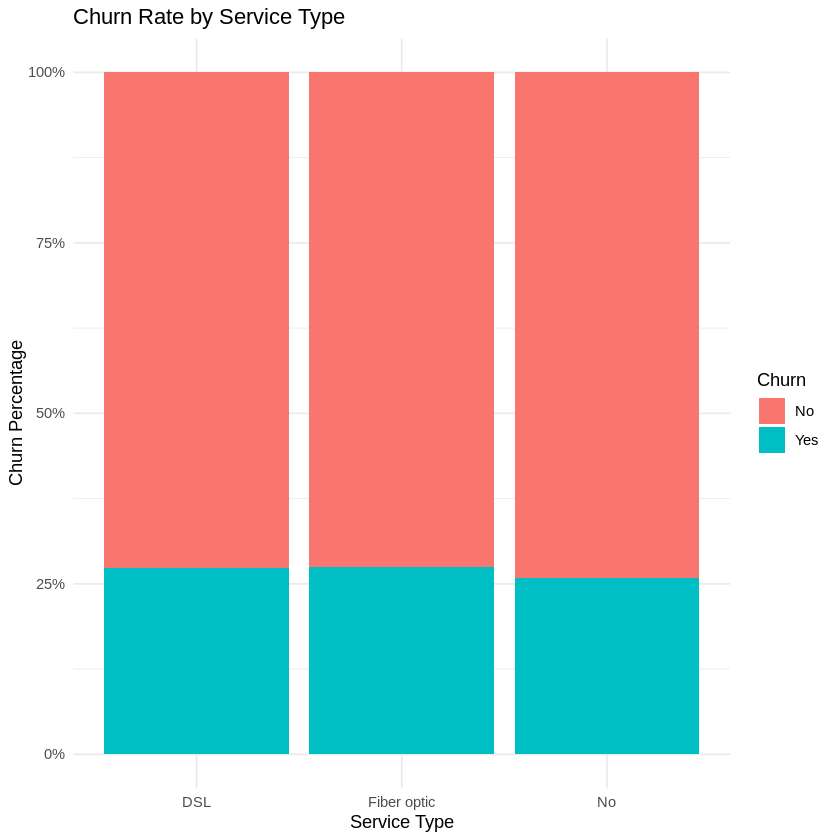

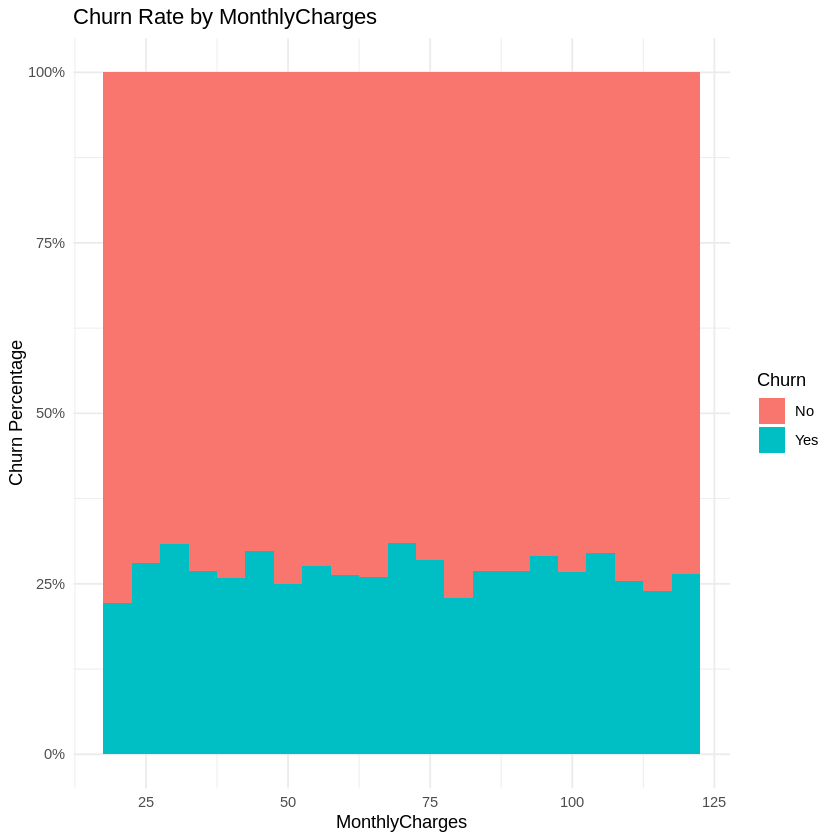

In [29]:
ggplot(customer_churn, aes(x=Tenure, fill=Churn)) +
  geom_histogram(binwidth=5, position="fill") +
  labs(title="Churn Rate by Tenure",
       x="Tenure (months)",
       y="Churn Percentage") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal()

ggplot(customer_churn, aes(x=InternetService, fill=Churn)) +
  geom_bar(position = "fill") +
  labs(title="Churn Rate by Service Type",
       x="Service Type",
       y="Churn Percentage") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal()

ggplot(customer_churn, aes(x=MonthlyCharges, fill=Churn)) +
  geom_histogram(binwidth=5, position="fill") +
  labs(title="Churn Rate by MonthlyCharges",
       x="MonthlyCharges",
       y="Churn Percentage") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal()

3. **Data Transformation**

*  Handle missing values appropriately.

*  Convert categorical variables into factor variables.

* Normalize or standardize numerical features where necessary.

In [38]:
# missing values
sum(is.na(customer_churn)) #shows that there are no missing values in the dataset

customer_churn_clean <- customer_churn %>%
  select(-CustomerID) %>%
  mutate(across(where(is.character), as.factor)) %>% # Convert categorical variables into factor variables
  mutate(SeniorCitizen = factor(SeniorCitizen,
        levels = c(0,1), labels = c("No","Yes"))) %>%
  mutate(across(c(Tenure, MonthlyCharges, TotalCharges), #  Normalize or standardize numerical features where necessary
           ~ scale(.) %>% as.vector()))

str(customer_churn_clean)

[1] 0

'data.frame':	10000 obs. of  11 variables:
 $ Gender         : Factor w/ 2 levels "Female","Male": 2 2 2 1 2 1 1 1 1 1 ...
 $ SeniorCitizen  : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Partner        : Factor w/ 2 levels "No","Yes": 1 1 2 2 1 1 2 2 2 1 ...
 $ Dependents     : Factor w/ 2 levels "No","Yes": 1 1 1 2 1 2 1 2 2 1 ...
 $ Tenure         : num  1.433 -0.444 0.903 1.673 0.855 ...
 $ PhoneService   : Factor w/ 2 levels "No","Yes": 2 2 2 2 2 2 2 2 1 2 ...
 $ InternetService: Factor w/ 3 levels "DSL","Fiber optic",..: 2 2 2 1 1 2 3 2 3 3 ...
 $ Contract       : Factor w/ 3 levels "Month-to-month",..: 1 1 1 2 1 1 2 1 1 3 ...
 $ MonthlyCharges : num  -1.727 -0.174 -0.717 -1.343 1.16 ...
 $ TotalCharges   : num  -0.622 -0.411 0.114 -0.147 1.644 ...
 $ Churn          : Factor w/ 2 levels "No","Yes": 1 1 1 1 2 2 2 2 1 1 ...


4. **Data Wrangling**

* Filter data to remove outliers.

* Create new derived variables that may help in predictive modeling.

* Aggregate or summarize data if necessary.

In [45]:
# Filter data to remove outliers.
remove_outliers <- function(x) {
  Q1 <- quantile(x, 0.25)
  Q3 <- quantile(x, 0.75)
  IQR <- Q3 - Q1

  x > (Q1 - 1.5 * IQR) & x < (Q3 + 1.5 * IQR)
}

customer_churn_filtered <- customer_churn_clean %>%
  filter(
   remove_outliers(Tenure),
   remove_outliers(MonthlyCharges),
   remove_outliers(TotalCharges)
  )

  dim(customer_churn_filtered) #72 rows were removed

# Create new derived variables that may help in predictive modeling.
customer_churn_derived <- customer_churn_filtered %>%
  mutate(AvgChargePerMonth = TotalCharges / pmax(Tenure, 1),
    HouseholdType = paste(Partner, Dependents, sep = "_")) %>%
  mutate(HouseholdType = factor(HouseholdType)) %>%
  select(-Partner, -Dependents)

str(customer_churn_derived)

# Aggregate or summarize data if necessary.
customer_churn_summary <- customer_churn_derived %>%
  group_by(Churn) %>%
  summarise(
    AvgTenure = mean(Tenure),
    AvgMonthlyCharges = mean(MonthlyCharges),
    AvgTotalCharges = mean(TotalCharges),
    AvgChargePerMonth = mean(AvgChargePerMonth),
    CustomerCount = n()
  )

str(customer_churn_summary)

contract_summary <- customer_churn_derived %>%
  group_by(Contract, Churn) %>%
  summarise(Customers = n(), .groups = "drop")

str(contract_summary)

[1] 9928   11

'data.frame':	9928 obs. of  11 variables:
 $ Gender           : Factor w/ 2 levels "Female","Male": 2 2 2 1 2 1 1 1 1 1 ...
 $ SeniorCitizen    : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Tenure           : num  1.433 -0.444 0.903 1.673 0.855 ...
 $ PhoneService     : Factor w/ 2 levels "No","Yes": 2 2 2 2 2 2 2 2 1 2 ...
 $ InternetService  : Factor w/ 3 levels "DSL","Fiber optic",..: 2 2 2 1 1 2 3 2 3 3 ...
 $ Contract         : Factor w/ 3 levels "Month-to-month",..: 1 1 1 2 1 1 2 1 1 3 ...
 $ MonthlyCharges   : num  -1.727 -0.174 -0.717 -1.343 1.16 ...
 $ TotalCharges     : num  -0.622 -0.411 0.114 -0.147 1.644 ...
 $ Churn            : Factor w/ 2 levels "No","Yes": 1 1 1 1 2 2 2 2 1 1 ...
 $ AvgChargePerMonth: num  -0.4341 -0.411 0.1136 -0.0878 1.6439 ...
 $ HouseholdType    : Factor w/ 4 levels "No_No","No_Yes",..: 1 1 3 4 1 2 3 4 4 1 ...
tibble [2 × 6] (S3: tbl_df/tbl/data.frame)
 $ Churn            : Factor w/ 2 levels "No","Yes": 1 2
 $ AvgTenure        : num 

5. **Review**
* Summarize key takeaways from the exploratory data analysis process.

The dataset had no NA values and no duplicate values, meaning the data set was already clean.

The visualization shows that churn rate stays consistently around the 25-30% mark across tenure, internet service type, and monthly charges. This means that this variables may not be able to predict customer churn.

To improve predictive modeling the following steps were done:
-Categorical variables were converted to factor variables.
-Numerical variables (Tenure, MonthlyCharges, TotalCharges) were standardized.
-Outliers were removed, which caused dataset to decrease by 72 rows.
-Derived variables were added.

# Unit 2: Tuning Predictive Models
6. **Model Complexity**

* Fit a decision tree and logistic regression model.

* Compare their complexities and explain trade-offs.

Logistic regression assumes that there is linear relationship between theindependent variables and the log-odds of customer churn. It is easier to interpret, because as seen it provides numerical values, such as coefficients and p-values. However, it may not show nonlinear relationships and complex interactions between variables.

Meanwhile decision tree can model complex, non-linear relationships by splitting data. However, they are prone to overfitting if not properly tuned.

Overall, a logistic regression is easily interpreted but is not very flexible, and a decision tree is more flexible but also unstable.

In [70]:
train_control <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE,
  summaryFunction = twoClassSummary,
  savePredictions = TRUE
)

log_model <- train(
  Churn ~ .,
  data = customer_churn_derived,
  method = "glm",
  family = "binomial",
  metric = "ROC",
  trControl = train_control
)

print(log_model)
summary(log_model$finalModel)

glm_model_base <- glm(
  Churn ~ .,
  data = customer_churn_derived,
  family = binomial
)


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


Generalized Linear Model 

9928 samples
  11 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 8935, 8935, 8935, 8935, 8936, 8935, ... 
Resampling results:

  ROC  Sens  Spec
  1    1     1   




Call:
NULL

Coefficients:
                               Estimate Std. Error z value Pr(>|z|)
(Intercept)                  -2.657e+01  1.442e+04  -0.002    0.999
GenderMale                    5.980e-13  7.159e+03   0.000    1.000
SeniorCitizenYes             -4.250e-13  1.001e+04   0.000    1.000
Tenure                        2.489e-13  9.646e+03   0.000    1.000
PhoneServiceYes               3.577e-13  1.211e+04   0.000    1.000
`InternetServiceFiber optic`  4.946e-13  7.990e+03   0.000    1.000
InternetServiceNo             9.432e-14  9.837e+03   0.000    1.000
`ContractOne year`           -4.165e-14  9.230e+03   0.000    1.000
`ContractTwo year`           -4.746e-13  9.220e+03   0.000    1.000
MonthlyCharges               -3.317e-15  7.375e+03   0.000    1.000
TotalCharges                 -1.777e-12  2.478e+04   0.000    1.000
AvgChargePerMonth             1.694e-12  2.779e+04   0.000    1.000
HouseholdTypeNo_Yes          -2.953e-13  1.113e+04   0.000    1.000
HouseholdTypeYes_No  

Warning message:
“glm.fit: algorithm did not converge”


CART 

9928 samples
  10 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 8935, 8935, 8935, 8935, 8935, 8936, ... 
Resampling results across tuning parameters:

  cp     ROC  Sens  Spec
  0.001  0.5  1     0   
  0.003  0.5  1     0   
  0.005  0.5  1     0   
  0.007  0.5  1     0   
  0.009  0.5  1     0   
  0.011  0.5  1     0   
  0.013  0.5  1     0   
  0.015  0.5  1     0   
  0.017  0.5  1     0   
  0.019  0.5  1     0   

ROC was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.019.


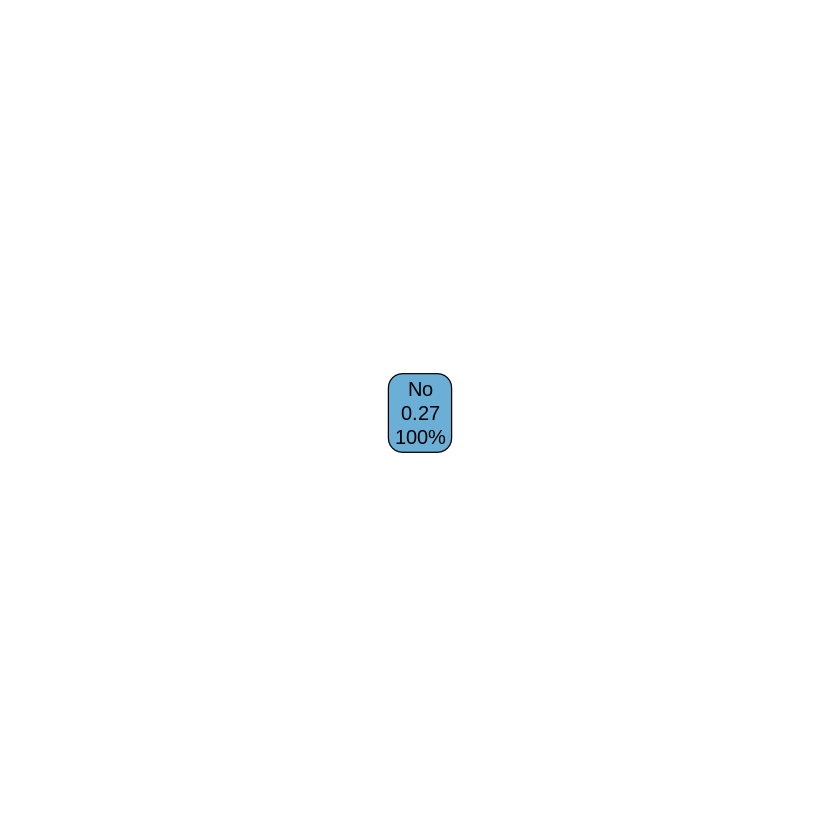

In [47]:
tree_grid <- expand.grid(
  cp = seq(0.001, 0.02, by = 0.002)
)

decision_tree_model <- train(
  Churn ~ .,
  data = customer_churn_derived,
  method = "rpart",
  metric = "ROC",
  tuneGrid = tree_grid,
  trControl = train_control,
  control = rpart.control(maxdepth = 5)
)

print(decision_tree_model)

# Plot the decision tree
rpart.plot(decision_tree_model$finalModel)

8. **Cross-Validation**

* Use k-fold cross-validation (k=10) to evaluate model performance.

* Report and interpret accuracy, precision, recall, and F1-score.

Accuracy (0.272 or 27.2%) is lower than the No Information Rate (72.9%), this means that the model performs worse if one were to randomly guessing.

Precision = 1.0 means that the model only predicts  a customer for churn when it is absolutely certain. This causes it to avoid False Positives, which results in churn guesses being perfect.

Recall = 0.0015 shows the model fails to detect churn cases, as it is near zero.

F1-score ≈ 0.003 confirms that there is a poor balance between precision and recall.

In [50]:
set.seed(123)

trainIndex <- createDataPartition(customer_churn_derived$Churn,
                                  p = 0.8,
                                  list = FALSE)

train_data <- customer_churn_derived[trainIndex, ]
test_data  <- customer_churn_derived[-trainIndex, ]

train_control <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE,
  sampling = "up",
  summaryFunction = twoClassSummary,
  savePredictions = "final"
)

model <- train(
  Churn ~ .,
  data = train_data,
  method = "glm",
  trControl = train_control,
  metric = "ROC",
  family = "binomial"
)

print(model)

prob <- predict(model, customer_churn_derived, type = "prob")

pred_class <- ifelse(prob$Yes > 0.4, "Yes", "No")
pred_class <- factor(pred_class, levels = c("No","Yes"))

conf_matrix <- confusionMatrix(pred_class,
                               customer_churn_derived$Churn)

print(conf_matrix)

accuracy <- conf_matrix$overall["Accuracy"]
precision <- conf_matrix$byClass["Pos Pred Value"]
recall <- conf_matrix$byClass["Sensitivity"]

f1_score <- (2 * precision * recall) / (precision + recall)

accuracy
precision
recall
f1_score

Generalized Linear Model 

7943 samples
  10 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 7148, 7149, 7149, 7149, 7149, 7149, ... 
Addtional sampling using up-sampling

Resampling results:

  ROC        Sens       Spec     
  0.5116075  0.5119171  0.5076443

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No    11    0
       Yes 7226 2691
                                         
               Accuracy : 0.2722         
                 95% CI : (0.2634, 0.281)
    No Information Rate : 0.7289         
    P-Value [Acc > NIR] : 1              
                                         
                  Kappa : 8e-04          
                                         
 Mcnemar's Test P-Value : <2e-16         
                                         
            Sensitivity : 0.001520       
            Specificity : 1.000000       
         Pos Pred Value : 1.000000       
    

Accuracy 
0.2721595

Pos Pred Value 
             1

Sensitivity 
0.001519967

Pos Pred Value 
    0.00303532

9. **Classification**

* Train a Random Forest classifier to predict customer churn.

* Tune hyperparameters using grid search.

* Report final model performance.

The parameter tuned was mtry, which is the number of variables sampled at each split. The following are the mtryand ROC results mtry = 2 ROC = 0.493, mtry = 4	ROC = 0.498, mtry = 6	ROC = 0.494, mtry = 8	ROC = 0.493.

The best model is mtry = 4, however the ROC is still only 0.498, which means it is only slightly better than randomly guessing.

The variables of importance are GenderMale, SeniorCitizenYes, Tenure, PhoneServiceYes, InternetServiceFiber optic, InternetServiceNo, ContractOne year, ContractTwo year, MonthlyCharges, TotalCharges, AvgChargePerMonth, HouseholdTypeNo_Yes, HouseholdTypeYes_No, HouseholdTypeYes_Yes. This means these are the variables that have the strongest influence when predicting churn.

In [58]:
rf_model <- train(
  Churn ~ .,
  data = train_data,
  method = "rf",
  metric = "ROC",
  trControl = train_control,
  tuneGrid = expand.grid(mtry = c(2,4,6,8)),
  ntree = 500,
  importance = TRUE
)

print(rf_model)
varImp(rf_model$finalModel)

Random Forest 

7943 samples
  10 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 7149, 7149, 7149, 7148, 7148, 7149, ... 
Resampling results across tuning parameters:

  mtry  ROC        Sens       Spec      
  2     0.4930368  1.0000000  0.00000000
  4     0.4976722  0.9692573  0.03064384
  6     0.4939080  0.9405872  0.05571921
  8     0.4934772  0.9366149  0.05849699

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 4.


,No,Yes
,<dbl>,<dbl>
GenderMale,1.7857417,1.7857417
SeniorCitizenYes,1.4020335,1.4020335
Tenure,1.2999829,1.2999829
PhoneServiceYes,-1.7802985,-1.7802985
InternetServiceFiber optic,-0.7359820,-0.7359820
InternetServiceNo,3.5483183,3.5483183
ContractOne year,-0.2175992,-0.2175992
ContractTwo year,-1.6690019,-1.6690019
MonthlyCharges,2.2340008,2.2340008


# Unit 3: Regression-Based Methods
10. **Logistic Regression**

* Fit a logistic regression model using Churn as the dependent variable and Tenure, MonthlyCharges, and TotalCharges as independent variables.

* Interpret the coefficients and assess model significance using p-values.

Tenure: The positive coefficient (0.0534) implies that as tenure increases, the log-odds of churn slightly increase, but as p-value = 0.367, this effect is not significant.

MonthlyCharges: The small positive coefficient (0.0163) implies that higher monthly bills might have a slight effect on churn probability, but as p-value = 0.718, this effect is not significant.

TotalCharges: The negative coefficient (-0.0487) implies that higher total charges may cause a light decrease in churn, but as p-value = 0.493 this effect is not significant.

Since all p-values > 0.05, all three variables are not strong predictors of churn in this specific model, which aligns with earlier visualizations.

In [62]:
glm_model_base <- glm(
  Churn ~ Tenure + MonthlyCharges + TotalCharges,
  data = customer_churn_derived,
  family = binomial
)

summary(glm_model_base)


Call:
glm(formula = Churn ~ Tenure + MonthlyCharges + TotalCharges, 
    family = binomial, data = customer_churn_derived)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.98967    0.02259 -43.808   <2e-16 ***
Tenure          0.05339    0.05913   0.903    0.367    
MonthlyCharges  0.01628    0.04512   0.361    0.718    
TotalCharges   -0.04872    0.07106  -0.686    0.493    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 11602  on 9927  degrees of freedom
Residual deviance: 11601  on 9924  degrees of freedom
AIC: 11609

Number of Fisher Scoring iterations: 4


11. **Regression in High Dimensions**

* Discuss the challenges of high-dimensional regression and potential solutions.

* Apply Principal Component Analysis (PCA) on numerical features (Tenure, MonthlyCharges, TotalCharges) to reduce dimensionality.


As high-dimensional datasets contain many predictors relative to observations, this can cause many challenges such as overfitting (the model memorizes instead of learning patterns) , multicollinearity (model struggles to see individual affects of variables), and interpretation issues (as seen earlier, there were a lot of 'important' variables which makes it confusing). Some potential solutions may include reducing of dimensionality (PCA), regularization (Ridge & Lasso) and feature selection.

In the code, using PCA showed that the first three components already explain about 98.66% of the total variance, meaning that the data can be effectively represented using fewer dimensions while still retaining most of the relevant information.

In [63]:
numeric_features <- customer_churn %>%
  select(where(is.numeric))

pca_model <- prcomp(numeric_features, scale = TRUE)

summary(pca_model)

Importance of components:
                          PC1    PC2    PC3     PC4
Standard deviation     1.3864 1.0127 0.9995 0.23128
Proportion of Variance 0.4805 0.2564 0.2497 0.01337
Cumulative Proportion  0.4805 0.7369 0.9866 1.00000

12. **Ridge Regression**

* Implement Ridge Regression using Churn as the target variable and Tenure, MonthlyCharges, TotalCharges, and additional customer demographic features as predictors.

* Identify the optimal lambda using cross-validation.

Optimal Lambda = 0.04445 which is the penalty parameter used to shrink the magnitude of regression coefficients toward zero, reduce variance and help stabilize the model in the presence of correlated predictors. This leads to a better generalization performance and reduces overfitting.

The coefficients are all close to zero, meaning that predictors do not have much influence.

[1] 0.04445027

16 x 1 sparse Matrix of class "dgCMatrix"
                              lambda.min
(Intercept)                -2.7827150794
GenderMale                 -0.0240405868
SeniorCitizenYes           -0.0099170999
Tenure                      0.0069011037
PhoneServiceYes            -0.0345829492
InternetServiceFiber optic  0.0056303521
InternetServiceNo          -0.0293794258
ContractOne year           -0.0510757796
ContractTwo year            0.0150435556
MonthlyCharges             -0.0025020272
TotalCharges               -0.0001978367
AvgChargePerMonth          -0.0037098621
HouseholdTypeNo_Yes         0.0171008742
HouseholdTypeYes_No         0.0099937095
HouseholdTypeYes_Yes       -0.0479185133
Churn_binary                4.5832257399

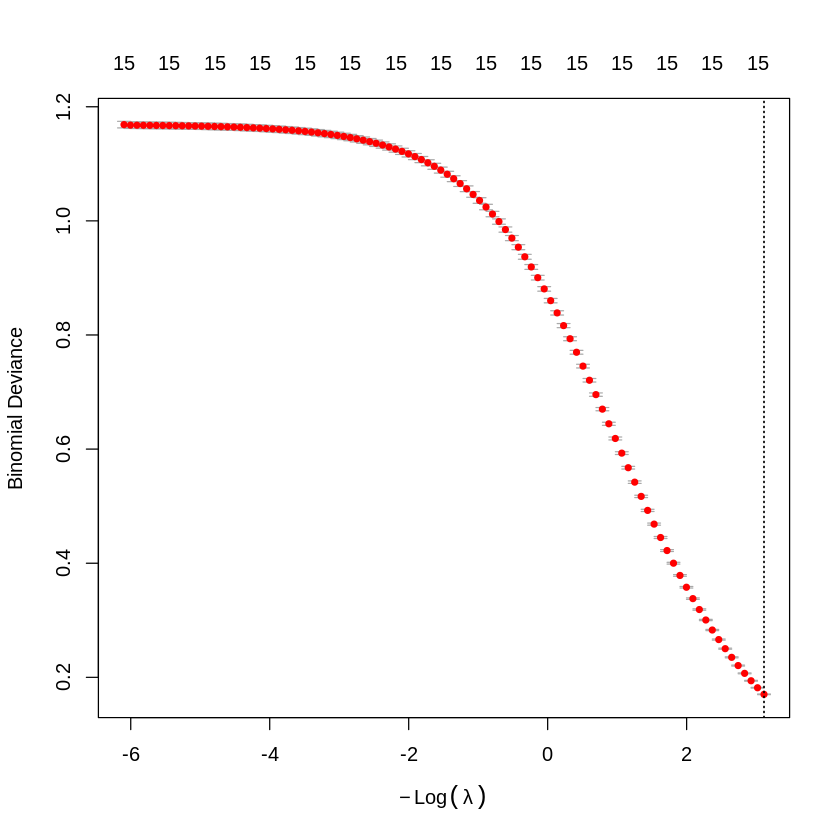

In [72]:
x <- model.matrix(Churn ~ ., customer_churn_derived)[,-1]
y <- customer_churn_derived$Churn

ridge_model <- cv.glmnet(
  x,
  y,
  family = "binomial",
  alpha = 0
)

best_lambda <- ridge_model$lambda.min
best_lambda

plot(ridge_model)

coef(ridge_model, s = "lambda.min")

13. **Lasso Regression**

* Implement Lasso Regression with the same feature set as Ridge Regression.

* Discuss feature selection benefits and interpret the coefficients.

The optimal lambda is 0.000601433338339672. Lasso has automatic feature selection through shrinking some coefficients exactly to zero. In the code, all but two coefficients, were reduced to zero. The only two coefficients left were ntercept = -7.9097 and Churn_binary = 14.8295. This suggests that Churn is almost entirely predicted from only Churn_binary, however Churn_binary is simply curn outcome. This means that while Lasso was able to achieve perfect prediction, it does not prodvide additional insight on variables that affect customer churn.


[1] 0.0006014333

16 x 1 sparse Matrix of class "dgCMatrix"
                           lambda.min
(Intercept)                 -7.909715
GenderMale                   .       
SeniorCitizenYes             .       
Tenure                       .       
PhoneServiceYes              .       
InternetServiceFiber optic   .       
InternetServiceNo            .       
ContractOne year             .       
ContractTwo year             .       
MonthlyCharges               .       
TotalCharges                 .       
AvgChargePerMonth            .       
HouseholdTypeNo_Yes          .       
HouseholdTypeYes_No          .       
HouseholdTypeYes_Yes         .       
Churn_binary                14.829515

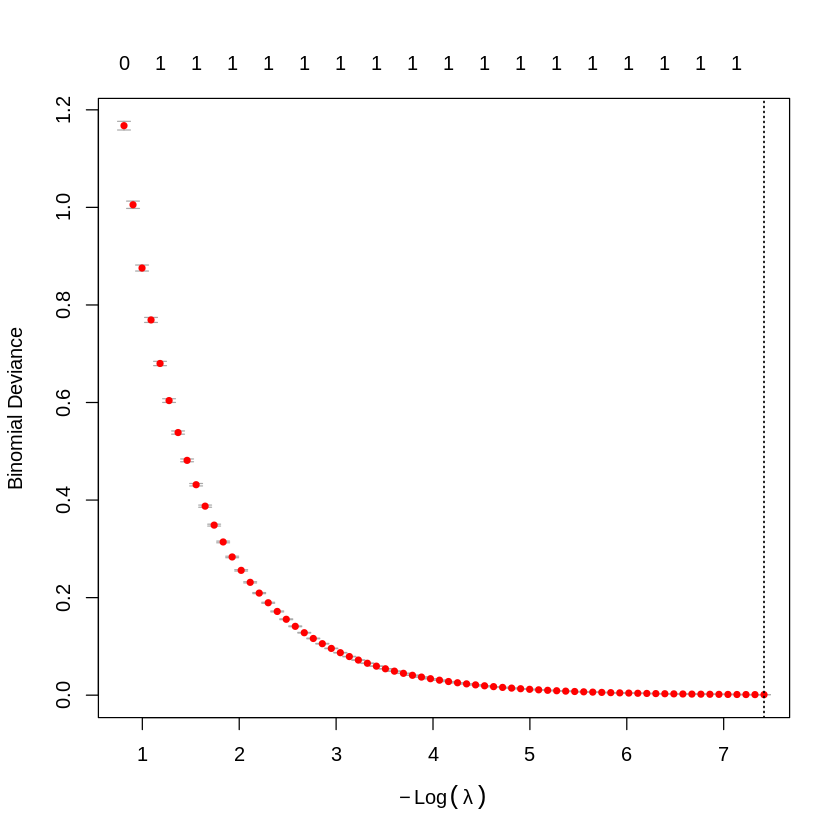

In [66]:
lasso_model <- cv.glmnet(x, y, family = "binomial", alpha = 1)

best_lambda_lasso <- lasso_model$lambda.min
best_lambda_lasso

plot(lasso_model)

coef(lasso_model, s = "lambda.min")